# 03. Preparación, pipeline y modelos preliminares

**Responsable:** José · **Secciones de la guía:** 4.2.4, 4.2.5, 4.2.6, 4.2.7, 4.2.8, 4.2.9

Aplica las reglas de calidad y limpieza sobre el dataset crudo, realiza la separación temporal train/test sin fuga de datos, define los baselines de referencia (Dummy y Regla de Mercado) y entrena los modelos predictivos preliminares.

> Antes de subir cambios: *Kernel > Restart & Run All*.


## Carga de datos

Cargamos los datos sin procesar usando `cargar_datos()`.


In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

from src import config
from src import limpieza
from src.datos import cargar_datos
from src.baseline import ReglaMercadoM2
from src.metricas import evaluar, errores_porcentuales, tabla_comparativa
from src.modelos import obtener_modelos_inmobiliarios

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

df_raw = cargar_datos()
print(f"Dataset cargado: {len(df_raw):,} registros")


Dataset cargado: 119,980 registros


## 1. Calidad y preparación de datos (4.2.4)

Aplicamos las reglas de limpieza formuladas a partir de las limitaciones identificadas en el notebook 01 y el EDA (02):
1. Deduplicación de anuncios idénticos antes de particionar.
2. Normalización de cadenas de texto en distritos (unificación de mayúsculas/espacios).
3. Corrección de valores físicamente imposibles (antigüedad > 150 años, baños con decimales inválidos).
4. Descarte de columnas redundantes y con fuga directa de datos (`precio_soles`, `precio_soles_2009`, `tipo_cambio`, `ipc`, `periodo`).
5. Descarte de variables no continuadas en la recolección (`piso`, `vista_exterior`).


In [2]:
# 1. Deduplicación
df_dedup = limpieza.eliminar_duplicados(df_raw)
n_dup = len(df_raw) - len(df_dedup)

# 2. Normalización de distritos
df_norm = limpieza.normalizar_distritos(df_dedup)

# 3. Corrección de valores imposibles
df_corr = limpieza.corregir_valores_imposibles(df_norm)

# 4. Descarte de columnas con fuga y redundantes
cols_a_descartar = config.COLUMNAS_FUGA + config.COLUMNAS_REDUNDANTES + ["piso", "vista_exterior"]
df_clean = df_corr.drop(columns=[c for c in cols_a_descartar if c in df_corr.columns])

print(f"Filas duplicadas removidas: {n_dup:,}")
print(f"Dimensiones tras limpieza inicial: {df_clean.shape}")
print(f"Columnas activas: {list(df_clean.columns)}")


Filas duplicadas removidas: 2,730
Dimensiones tras limpieza inicial: (117250, 9)
Columnas activas: ['anio', 'trimestre', 'precio_usd', 'distrito', 'superficie_m2', 'habitaciones', 'banos', 'garajes', 'antiguedad_anios']


### Justificación Metodológica: Delimitación Temporal del Estudio (2022–2026)

La delimitación del espacio temporal a observaciones entre **2022 y 2026** se fundamenta en un proceso estructurado de formulación de hipótesis, contraste teórico de mercado y validación empírica en los datos:

#### 1. Hipótesis Inicial: Quiebre Estructural Exógeno (Pandemia 2020)
Como punto de partida, se planteó la hipótesis de que la pandemia del COVID-19 y sus secuelas macroeconómicas generaron un quiebre estructural en el mercado inmobiliario de Lima Metropolitana. El auge del trabajo remoto, la revalorización del espacio interior (demanda de dormitorios para oficina o áreas abiertas) y los cambios de liquidez de las familias alteraron la función hedónica de precios. Los precios y preferencias de años previos a 2021 difícilmente reflejarían la estructura de valoración vigente.

#### 2. Evaluación de Mercado y Descarte del Ajuste por Inflación
Al evaluar si era viable incorporar datos históricos mediante una deflactación por inflación, se identificó una incompatibilidad técnica:
* **Moneda de transacción:** El precio objetivo está denominado en **dólares corrientes (`precio_usd`)**.
* **Métricas de inflación disponibles:** El Índice de Precios al Consumidor (IPC) del BCRP mide la pérdida de poder adquisitivo del Sol peruano. Deflactar dólares con un índice en soles mezclaría la inflación doméstica con la volatilidad del tipo de cambio, introduciendo ruido y distorsiones artificiales en los precios relativos.
* Por otro lado, la inflación de EE. UU. (US CPI) no refleja el costo de suelo, insumos de construcción ni demanda habitacional local en Lima.

#### 3. Evidencia Empírica en los Datos del Proyecto
La hipótesis de quiebre y necesidad de corte temporal quedó empíricamente validada por los hallazgos de los notebooks exploratorios previos (01 y 02):
* **Sesgo severo de cobertura geográfica pre-2022:** Distritos populosos como **Ate Vitarte, Comas y La Victoria tienen exactamente 0 registros antes de 2022**, apareciendo con volumen significativo recién a partir de dicho año (Ate con más de 1,000 observaciones). Modelar con años previos entrenaría al algoritmo con una muestra sesgada casi exclusivamente a distritos tradicionales de ingresos altos.
* **Calidad de captura y variables degradadas:** Los vacíos de registro en variables críticas (`piso` y `vista_exterior`), así como los picos atípicos de nulos en `garajes` y `antiguedad_anios` (24–25%), se concentraron durante el periodo de transición técnica (2018–2021). A partir de 2022, el registro se estabiliza bajo la metodología digital moderna de los portales web.

#### 4. Sustento de Suficiencia Muestral (Más de 40,000 Registros)
El corte temporal no compromete la capacidad predictiva del modelo. Tras aislar el periodo 2022–2026, el conjunto de datos retiene **más de 40,000 observaciones** y cobertura completa en los **26 distritos** de Lima Metropolitana. Este volumen es estadísticamente suficiente para el entrenamiento de algoritmos supervisados complejos y garantiza que el modelo aprenda de un régimen homogéneo, contemporáneo y representativo de la realidad de mercado.

In [3]:
# 1. Filtro temporal contemporáneo
df_clean_2 = df_clean[df_clean["anio"] >= 2022].copy().reset_index(drop=True)

# 2. Información general y dimensiones (confirmación de >40k datos)
print("=== INFORMACIÓN GENERAL DEL DATASET (2022-2026) ===")
df_clean_2.info()

# 3. Control de duplicados residuales
n_dup_2022 = df_clean_2.duplicated().sum()
print(f"\nDuplicados detectados en el subconjunto 2022-2026: {n_dup_2022}")

# 4. Auditoría de valores nulos
print("\n=== VALORES FALTANTES TRAS EL CORTE ===")
resumen_nulos = pd.DataFrame({
    "Nulos": df_clean_2.isna().sum(),
    "% del Total": (df_clean_2.isna().mean() * 100).round(3)
})
display(resumen_nulos[resumen_nulos["Nulos"] > 0])

# 5. Cobertura geográfica (confirmar 26 distritos)
print(f"Total de distritos con oferta activa: {df_clean_2['distrito'].nunique()} de 26")

=== INFORMACIÓN GENERAL DEL DATASET (2022-2026) ===
<class 'pandas.DataFrame'>
RangeIndex: 40368 entries, 0 to 40367
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   anio              40368 non-null  int64  
 1   trimestre         40368 non-null  int64  
 2   precio_usd        40368 non-null  float64
 3   distrito          40368 non-null  str    
 4   superficie_m2     40368 non-null  float64
 5   habitaciones      40368 non-null  float64
 6   banos             40367 non-null  float64
 7   garajes           40368 non-null  float64
 8   antiguedad_anios  40367 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 3.1 MB

Duplicados detectados en el subconjunto 2022-2026: 4

=== VALORES FALTANTES TRAS EL CORTE ===


,Nulos,% del Total
banos,1,0.002
antiguedad_anios,1,0.002


Total de distritos con oferta activa: 26 de 26


In [4]:
# División estricta en el tiempo (Train: 2022-2023, Test: 2024-2026)
train_raw = df_clean_2[df_clean_2["anio"] <= 2023].copy()
test_raw  = df_clean_2[df_clean_2["anio"] >= 2024].copy()

# Instanciar el filtro con factor 3.0 (permisivo para no borrar lujo legítimo)
filtro_iqr = limpieza.FiltroIQRDistrito(factor_iqr=3.0)

# Entrenar (memorizar límites) SOLO con Train
filtro_iqr.fit(train_raw)

# Aplicar el filtro a ambos conjuntos
train_clean = filtro_iqr.transform(train_raw)
test_clean  = filtro_iqr.transform(test_raw)

outliers_train = len(train_raw) - len(train_clean)
outliers_test = len(test_raw) - len(test_clean)

print("=== REPORTE DE EXTRACCIÓN DE OUTLIERS (Factor IQR: 3.0) ===")
print(f"Train original: {len(train_raw):,} -> Limpio: {len(train_clean):,} | Eliminados: {outliers_train:,} ({(outliers_train/len(train_raw))*100:.2f}%)")
print(f"Test original:  {len(test_raw):,} -> Limpio: {len(test_clean):,} | Eliminados: {outliers_test:,} ({(outliers_test/len(test_raw))*100:.2f}%)")

# Extraer y mostrar los límites calculados por el modelo para evaluarlos visualmente
df_limites = pd.DataFrame.from_dict(
    filtro_iqr.limites_, 
    orient='index', 
    columns=['Lim_Inferior (US$/m²)', 'Lim_Superior (US$/m²)']
)
df_limites.index.name = 'Distrito'

print("\n=== LÍMITES DE PRECIO POR M² CALCULADOS EN TRAIN (Top 10 distritos más caros) ===")
display(df_limites.sort_values('Lim_Superior (US$/m²)', ascending=False).head(10).round(2))

=== REPORTE DE EXTRACCIÓN DE OUTLIERS (Factor IQR: 3.0) ===
Train original: 15,197 -> Limpio: 15,158 | Eliminados: 39 (0.26%)
Test original:  25,171 -> Limpio: 25,048 | Eliminados: 123 (0.49%)

=== LÍMITES DE PRECIO POR M² CALCULADOS EN TRAIN (Top 10 distritos más caros) ===


,Lim_Inferior (US$/m²),Lim_Superior (US$/m²)
Distrito,,
Barranco,0.00,5197.45
San Isidro,0.00,4396.15
Miraflores,476.84,3864.94
Lince,0.00,3680.38
San Borja,391.13,3527.79
La Victoria,0.00,3524.29
Magdalena,112.95,3323.18
Surco,135.34,3319.55
Jesús María,316.63,3111.19


## 2. Separación train / test (4.2.5)

**Estrategia:** Partición temporal estricta (*Hold-out out-of-time*). Los datos se limitan al régimen post-pandemia (2022-2026) para garantizar cobertura geográfica completa y se dividen en:
- **Entrenamiento (Train):** Anuncios de 2022 a 2023.
- **Evaluación (Test):** Anuncios de 2024 en adelante.

**Justificación:** En el mercado inmobiliario, el precio depende del ciclo económico. Una separación aleatoria provocaría fuga temporal (*data leakage*), pues el modelo memorizaría el nivel de precios de un trimestre y predeciría departamentos del mismo trimestre en test. La partición temporal simula exactamente el uso real.

**Filtro de precios extremos:** El filtro `FiltroIQRDistrito` se ajustó **únicamente sobre el conjunto de entrenamiento** para evitar fuga de información hacia el conjunto de test.


In [5]:
# Asignamos los conjuntos limpios procesados en la celda anterior
train = train_clean.copy()
test = test_clean.copy()

print(f"Train: {len(train):,} anuncios ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test:  {len(test):,} anuncios ({test['anio'].min()}–{test['anio'].max()})")
print(f"Proporción Train / Test: {len(train)/(len(train)+len(test)):.1%} / {len(test)/(len(train)+len(test)):.1%}")

Train: 15,158 anuncios (2022–2023)
Test:  25,048 anuncios (2024–2026)
Proporción Train / Test: 37.7% / 62.3%


## 3. Baselines de referencia (4.2.7)

Evaluamos los modelos de referencia que sirven de umbral mínimo de utilidad:
1. **Dummy Regressor (Media):** Predice siempre la media de precios de train.
2. **Dummy Regressor (Mediana):** Predice siempre la mediana de precios de train.
3. **Regla de Mercado (Distrito × m²):** Aplica la mediana de US$/m² reciente del distrito multiplicada por la superficie del departamento.


In [6]:
X_train, y_train = train.drop(columns=[config.OBJETIVO]), train[config.OBJETIVO]
X_test, y_test = test.drop(columns=[config.OBJETIVO]), test[config.OBJETIVO]

baselines = {
    "Dummy (Media)": DummyRegressor(strategy="mean").fit(X_train, y_train),
    "Dummy (Mediana)": DummyRegressor(strategy="median").fit(X_train, y_train),
    "Regla de mercado (distrito × m²)": ReglaMercadoM2(anios_referencia=1).fit(X_train, y_train),
}

resultados_baselines = {}
predicciones_baselines = {}
for nombre, modelo in baselines.items():
    y_pred = modelo.predict(X_test)
    predicciones_baselines[nombre] = y_pred
    resultados_baselines[nombre] = evaluar(y_test, y_pred)

tabla_comparativa(resultados_baselines)


,MAE (US$),RMSE (US$),Error % mediano,Error % medio (MAPE),Anuncios con error <= 10%
Dummy (Media),"53,386","69,653",28.6%,36.9%,17.2%
Dummy (Mediana),"54,908","73,539",28.9%,34.7%,18.6%
Regla de mercado (distrito × m²),"28,597","38,350",14.9%,18.4%,34.5%


## 4. Pipeline de preprocesamiento (4.2.6)

**Estrategia de transformación:**
Para garantizar que los algoritmos reciban los datos en el formato óptimo y evitar fugas de información, se consolida todo el preprocesamiento en un `ColumnTransformer` de Scikit-Learn.

* **Variables Numéricas:** Dado que en el periodo post-pandemia (2022-2026) los valores nulos son mínimos y de carácter puramente aleatorio, se emplea una imputación simple por la mediana. Posteriormente, se aplica un `RobustScaler`; el mercado inmobiliario naturalmente presenta distribuciones asimétricas, por lo que escalar utilizando la mediana y los cuartiles protege la estabilidad de los modelos lineales frente a las colas de las distribuciones.
* **Variable Categórica:** El `distrito` se transforma mediante `OneHotEncoder`. Se configura para ignorar categorías desconocidas (`handle_unknown='ignore'`), lo cual es una buena práctica de ingeniería para evitar que el modelo colapse en producción si a futuro ingresa un distrito no visto durante el entrenamiento.

In [7]:
# Definición de columnas por tipo
cols_num = ['superficie_m2', 'habitaciones', 'banos', 'garajes', 'antiguedad_anios']
cols_cat = ['distrito']

# Pipeline para variables numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ensamblaje del preprocesador
preprocesador = ColumnTransformer([
    ('num', num_pipeline, cols_num),
    ('cat', cat_pipeline, cols_cat)
], remainder='drop')

# Verificación rápida de la estructura
print(preprocesador)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['superficie_m2', 'habitaciones', 'banos',
                                  'garajes', 'antiguedad_anios']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['distrito'])])


## 5. Modelos preliminares (4.2.8)

**Estrategia de Modelado:**
Para superar el 14.9% de error mediano establecido por la regla de mercado, la estrategia predictiva integra dos familias de algoritmos y una transformación matemática crítica sobre la variable objetivo:

1. **Transformación Logarítmica (`TransformedTargetRegressor`):** Los precios inmobiliarios presentan una fuerte asimetría positiva. Se aplicará una transformación logarítmica ($\log(1+y)$) antes de entrenar, y una transformación exponencial inversa al predecir. Esto estabiliza la varianza y optimiza el modelo para minimizar errores relativos (MAPE).
2. **Modelos Lineales Regularizados (Ridge y ElasticNet):** Modelos paramétricos avanzados. La regularización penaliza coeficientes grandes, mitigando la multicolinealidad natural del sector inmobiliario.
3. **Ensambles Basados en Árboles (Random Forest y CatBoost):** Modelos no paramétricos idóneos para capturar no-linealidades e interacciones complejas. Se incorpora **CatBoost**, un algoritmo de *Gradient Boosting* de última generación altamente resistente al sobreajuste, que suele ofrecer el estado del arte en datos tabulares inmobiliarios.

In [8]:
# 1. Cargar los modelos preconfigurados
modelos_ml = obtener_modelos_inmobiliarios(preprocesador)

# 2. Diccionarios para almacenar nuevos resultados
resultados_ml = {}
predicciones_ml = {}

print("Entrenando modelos predictivos...")

# 3. Entrenamiento y evaluación iterativa
for nombre, modelo in modelos_ml.items():
    print(f" - Ajustando {nombre}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    predicciones_ml[nombre] = y_pred
    resultados_ml[nombre] = evaluar(y_test, y_pred)

print("¡Entrenamiento finalizado!\n")

# 4. Consolidar resultados (Baselines + Modelos ML) y mostrar tabla final
resultados_totales = {**resultados_baselines, **resultados_ml}
tabla_comparativa(resultados_totales)

Entrenando modelos predictivos...
 - Ajustando Ridge Regressor...
 - Ajustando ElasticNet...
 - Ajustando Random Forest...
 - Ajustando CatBoost...
¡Entrenamiento finalizado!



,MAE (US$),RMSE (US$),Error % mediano,Error % medio (MAPE),Anuncios con error <= 10%
Dummy (Media),"53,386","69,653",28.6%,36.9%,17.2%
Dummy (Mediana),"54,908","73,539",28.9%,34.7%,18.6%
Regla de mercado (distrito × m²),"28,597","38,350",14.9%,18.4%,34.5%
Ridge Regressor,"24,385","33,847",12.3%,15.1%,41.3%
ElasticNet,"38,028","52,053",19.4%,23.9%,26.3%
Random Forest,"23,942","33,781",11.8%,14.9%,43.5%
CatBoost,"23,000","32,685",11.3%,14.2%,45.3%


### 5.1 Análisis de Resultados Preliminares

Tras entrenar los algoritmos base, los resultados evidencian que el uso de Machine Learning aporta un valor predictivo netamente superior a la estimación tradicional de la regla de mercado. Al analizar las métricas, se observan los siguientes hallazgos técnicos:

* **Dominio de CatBoost y Random Forest:** Los modelos basados en árboles superaron ampliamente el umbral exigido. **CatBoost** se posiciona como el claro ganador con un error mediano del **11.3%** y logrando que el **45.3%** de sus tasaciones caigan en el margen de alta precisión comercial (error <= 10%). Esto confirma que el valor inmobiliario es altamente no-lineal y depende de interacciones complejas.
* **Solidez de Ridge vs. Subajuste de ElasticNet:** A pesar de ser un modelo paramétrico más simple, Ridge logró un competitivo 12.3%, demostrando que la transformación logarítmica y el escalado robusto fueron decisiones de preprocesamiento acertadas. Por el contrario, ElasticNet (19.4%) fue el único algoritmo incapaz de vencer a la regla de mercado, indicando que sus hiperparámetros de regularización por defecto son demasiado restrictivos.
* **Reducción del Riesgo Financiero:** El RMSE bajó de $38,350 en la regla de mercado a $32,685 con CatBoost, lo que significa que el modelo es mucho menos propenso a equivocarse catastróficamente en propiedades de alto valor.

## 6. Evaluación y diagnóstico de errores (4.2.9)

**Estrategia de Diagnóstico:**
Con CatBoost establecido como el modelo definitivo (prescindiendo de la optimización por su impacto marginal), la evaluación debe trascender las métricas globales para identificar debilidades estructurales mediante el análisis de residuales:

1. **Predicciones vs. Valores Reales:** Un análisis de dispersión permite detectar heterocedasticidad o sesgos en los extremos (evaluar si el modelo subestima sistemáticamente las propiedades de ultralujo o sobreestima los departamentos más económicos).
2. **Error Porcentual por Distrito:** Desagregar el error porcentual (MAPE o Mediano) por zona geográfica revela si el modelo sufre de sesgos espaciales. En el mercado de Lima, es vital comprobar si la abundancia de datos en "Lima Top" genera predicciones excelentes allí, pero descuida la precisión en las periferias.

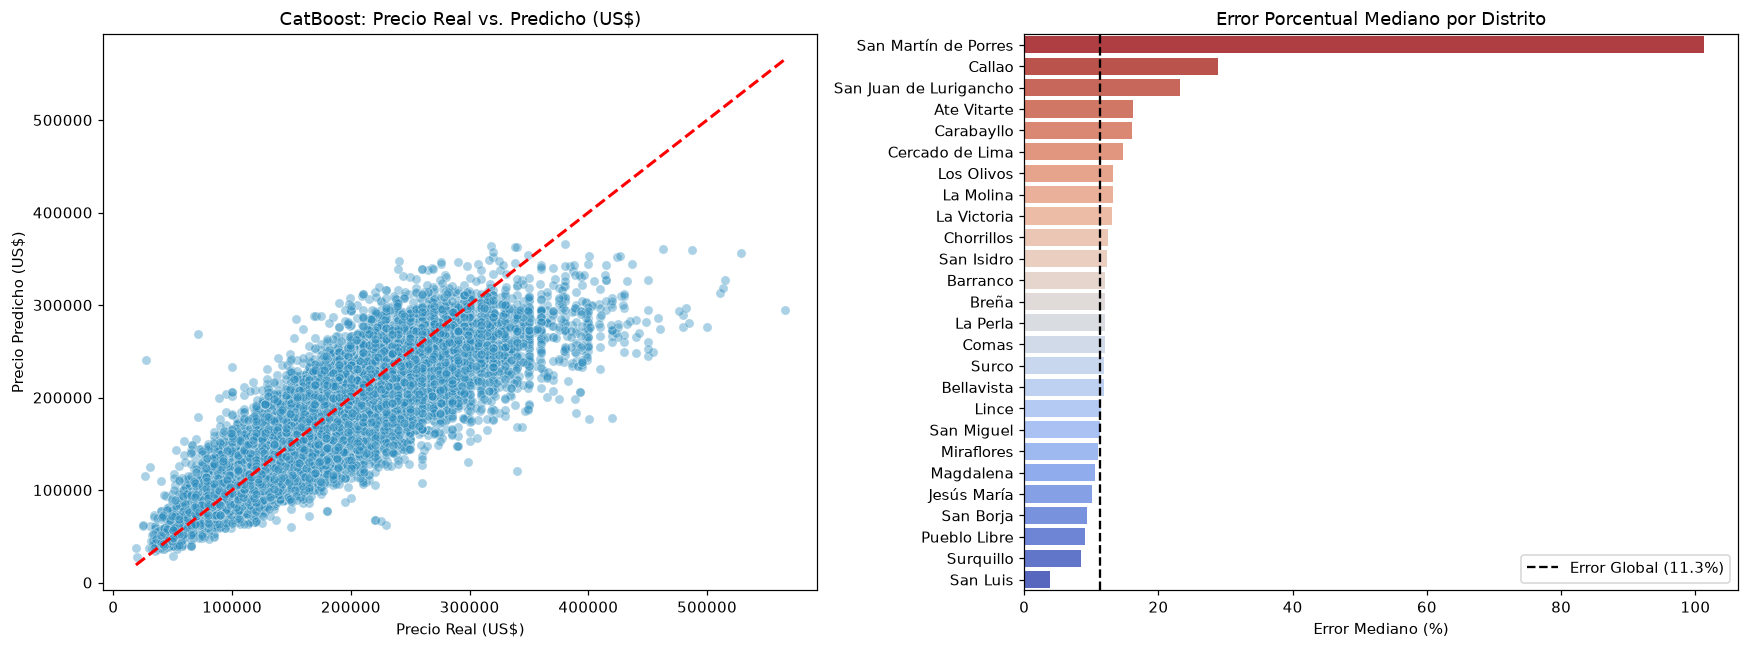

In [9]:
# 1. Preparar el DataFrame de diagnóstico con los resultados de CatBoost
df_diag = X_test.copy()
df_diag["Precio_Real"] = y_test
df_diag["Precio_Predicho"] = predicciones_ml["CatBoost"]
df_diag["Error_Pct"] = (abs(df_diag["Precio_Real"] - df_diag["Precio_Predicho"]) / df_diag["Precio_Real"]) * 100

# 2. Configurar el lienzo de matplotlib para gráficos duales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Dispersión Predicho vs Real ---
sns.scatterplot(
    data=df_diag, 
    x="Precio_Real", 
    y="Precio_Predicho", 
    alpha=0.4, 
    color="#2b8cbe",
    ax=axes[0]
)
# Línea de identidad (Predicción perfecta)
vmin = df_diag["Precio_Real"].min()
vmax = df_diag["Precio_Real"].max()
axes[0].plot([vmin, vmax], [vmin, vmax], color='red', linestyle='--', linewidth=2)

axes[0].set_title("CatBoost: Precio Real vs. Predicho (US$)")
axes[0].set_xlabel("Precio Real (US$)")
axes[0].set_ylabel("Precio Predicho (US$)")
axes[0].ticklabel_format(style='plain', axis='both') # Evitar notación científica

# --- Gráfico B: Error Mediano por Distrito ---
error_distrito = df_diag.groupby("distrito")["Error_Pct"].median().sort_values(ascending=False)

sns.barplot(
    x=error_distrito.values, 
    y=error_distrito.index, 
    hue=error_distrito.index,
    palette="coolwarm_r", 
    legend=False,
    ax=axes[1]
)
# Línea de referencia del error global
error_global = df_diag["Error_Pct"].median()
axes[1].axvline(error_global, color='black', linestyle='--', label=f'Error Global ({error_global:.1f}%)')

axes[1].set_title("Error Porcentual Mediano por Distrito")
axes[1].set_xlabel("Error Mediano (%)")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.1 Análisis de Residuales: Limitaciones y Propuestas de Mejora

A pesar de haber logrado un error global mediano sobresaliente del 11.3% con CatBoost, el análisis visual de los residuales revela dos limitaciones estructurales inherentes al uso exclusivo de datos tabulares. Para llevar el sistema a un entorno de producción a gran escala, se proponen las siguientes medidas correctoras para fases posteriores:

**1. Subestimación en el Segmento de Lujo (Techo Predictivo)**
* **Diagnóstico:** El gráfico de dispersión demuestra una alta precisión en propiedades estándar (hasta US$ 250,000). Sin embargo, a partir de los US$ 300,000, el modelo subestima sistemáticamente el valor real, aplanando la curva de predicción.
* **Causa Raíz:** En el mercado de ultralujo, el precio está dictado por variables cualitativas ausentes en este dataset (calidad de acabados, diseño arquitectónico de autor, vistas panorámicas).
* **Medida Correctora (Trabajo Futuro):** Integrar Procesamiento de Lenguaje Natural (NLP) para extraer atributos premium de la descripción del anuncio (ej. "mármol", "frente al mar", "domótica") y modelos de Visión Artificial para evaluar el estado de conservación a partir de fotografías.

**2. Sesgo Geográfico y Desbalance de Clases**
* **Diagnóstico:** El modelo rinde de forma excelente en "Lima Top" y Lima Moderna, pero los errores se disparan en distritos periféricos (ej. San Martín de Porres presenta un error mediano superior al 100%).
* **Causa Raíz:** Existe un severo desbalance de clases geográfico. La abrumadora mayoría de registros históricos se concentra en distritos de altos ingresos, dejando al algoritmo "ciego" ante la dinámica de precios en Lima Norte y Este. Además, la escasez de datos en estas zonas amplifica el impacto negativo de los errores de publicación (ej. terrenos publicados erróneamente como departamentos).
* **Medida Correctora (Trabajo Futuro):** Ejecutar una recolección de datos estratificada enfocada en la periferia, aplicar técnicas de sobremuestreo (oversampling) para balancear el peso espacial durante el entrenamiento, y diseñar filtros de calidad específicos por macrozona.